# Santiago Baeza

# Análisis de Sensibilidad

# Tarea 2 - 14/09/2026

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as si

Parte 1. Simulación de puts y calls

In [3]:
S0 = 100  # (Precio del activo)
K = 100  # (Precio de ejercicio (Strike))
r = 0.05  # (Tasa libre de riesgo)
sigma = 0.20   # (Volatilidad)
T = 1   # (Tiempo de expiración)
M = 10000   # (Número de simulaciones)

Black-Scholes

In [4]:
def black_scholes(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == 'call':
        price = S * si.norm.cdf(d1, 0.0, 1.0) - K * np.exp(-r * T) * si.norm.cdf(d2, 0.0, 1.0)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * si.norm.cdf(-d2, 0.0, 1.0) - S * si.norm.cdf(-d1, 0.0, 1.0)
    return price


In [27]:
bs_call = black_scholes(S0, K, T, r, sigma, 'call')
bs_put = black_scholes(S0, K, T, r, sigma, 'put')

print(bs_call)
print(bs_put)

10.450583572185565
5.573526022256971


Simulación Monte Carlo

In [ ]:
def monte_carlo_option(S, K, T, r, sigma, M, option_type='call'):
    np.random.seed(42) 
    Z = np.random.standard_normal(M)
    ST = S * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)
    
    if option_type == 'call':
        payoff = np.maximum(ST - K, 0)
    elif option_type == 'put':
        payoff = np.maximum(K - ST, 0)
        
    return np.exp(-r * T) * np.mean(payoff)

In [43]:
mc_call = monte_carlo_option(S0, K, T, r, sigma, M, 'call')
mc_put = monte_carlo_option(S0, K, T, r, sigma, M, 'put')

print(mc_call)
print(mc_put)

10.450169921134655
5.601717175958083


Parte 2. Sensibilidad

In [45]:
sensibilidades = {
    'Precio del Activo (S0)': (np.array([80, 90, 100, 110, 120]), 'S'),
    'Strike (K)': (np.array([80, 90, 100, 110, 120]), 'K'),
    'Volatilidad (sigma)': (np.array([0.10, 0.20, 0.30, 0.40, 0.50]), 'sigma'),
    'Tiempo (T)': (np.array([0.25, 0.5, 1.0, 1.5, 2.0]), 'T'),
    'Rendimiento (r)': (np.array([0.05, 0.10, 0.15, 0.20]), 'r')
}

Parte 3. Visualización

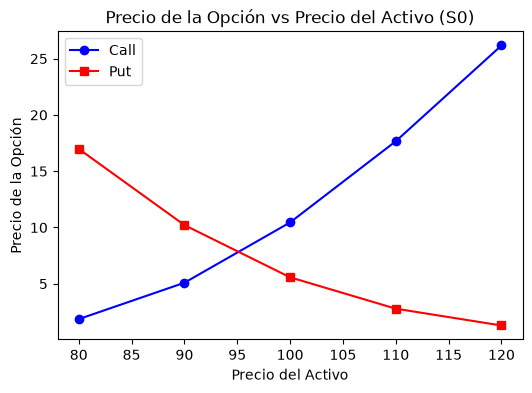

In [32]:
precios_activo = np.array([80, 90, 100, 110, 120])

calls_S = [black_scholes(S, K, T, r, sigma, 'call') for S in precios_activo]
puts_S  = [black_scholes(S, K, T, r, sigma, 'put') for S in precios_activo]

plt.figure(figsize=(6, 4))
plt.plot(precios_activo, calls_S, marker='o', color='blue', label='Call')
plt.plot(precios_activo, puts_S, marker='s', color='red', label='Put')
plt.title('Precio de la Opción vs Precio del Activo (S0)')
plt.xlabel('Precio del Activo')
plt.ylabel('Precio de la Opción')
plt.legend()
plt.show()

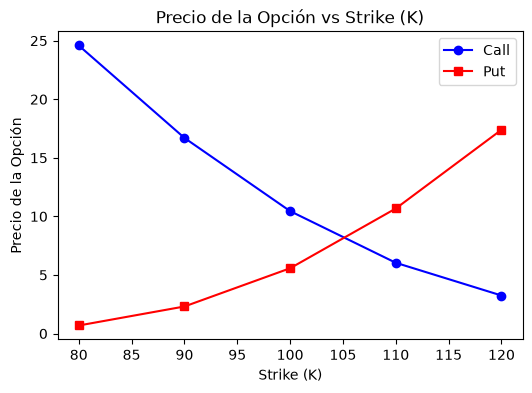

In [33]:
strikes = np.array([80, 90, 100, 110, 120])

calls_K = [black_scholes(S0, K, T, r, sigma, 'call') for K in strikes]
puts_K  = [black_scholes(S0, K, T, r, sigma, 'put') for K in strikes]

plt.figure(figsize=(6, 4))
plt.plot(strikes, calls_K, marker='o', color='blue', label='Call')
plt.plot(strikes, puts_K, marker='s', color='red', label='Put')
plt.title('Precio de la Opción vs Strike (K)')
plt.xlabel('Strike (K)')
plt.ylabel('Precio de la Opción')
plt.legend()
plt.show()

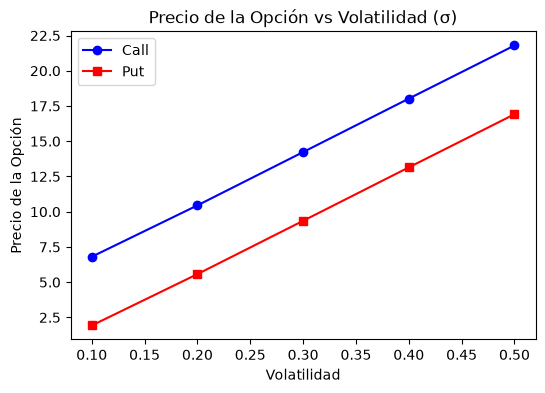

In [37]:
volatilidades = np.array([0.10, 0.20, 0.30, 0.40, 0.50])

calls_sig = [black_scholes(S0, K, T, r, sigma, 'call') for sigma in volatilidades]
puts_sig  = [black_scholes(S0, K, T, r, sigma, 'put') for sigma in volatilidades]

plt.figure(figsize=(6, 4))
plt.plot(volatilidades, calls_sig, marker='o', color='blue', label='Call')
plt.plot(volatilidades, puts_sig, marker='s', color='red', label='Put')
plt.title('Precio de la Opción vs Volatilidad (\u03C3)')
plt.xlabel('Volatilidad')
plt.ylabel('Precio de la Opción')
plt.legend()
plt.show()

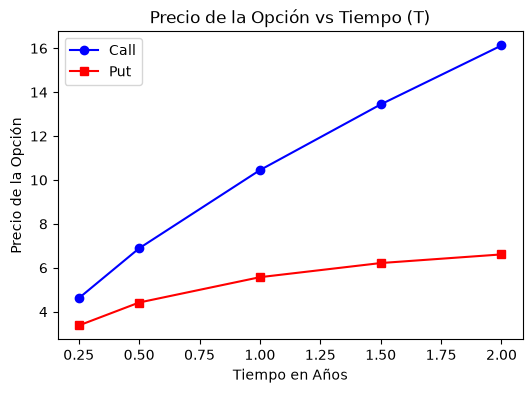

In [38]:
tiempos = np.array([0.25, 0.5, 1.0, 1.5, 2.0])

calls_T = [black_scholes(S0, K, T, r, sigma, 'call') for T in tiempos]
puts_T  = [black_scholes(S0, K, T, r, sigma, 'put') for T in tiempos]

plt.figure(figsize=(6, 4))
plt.plot(tiempos, calls_T, marker='o', color='blue', label='Call')
plt.plot(tiempos, puts_T, marker='s', color='red', label='Put')
plt.title('Precio de la Opción vs Tiempo (T)')
plt.xlabel('Tiempo en Años')
plt.ylabel('Precio de la Opción')
plt.legend()
plt.show()

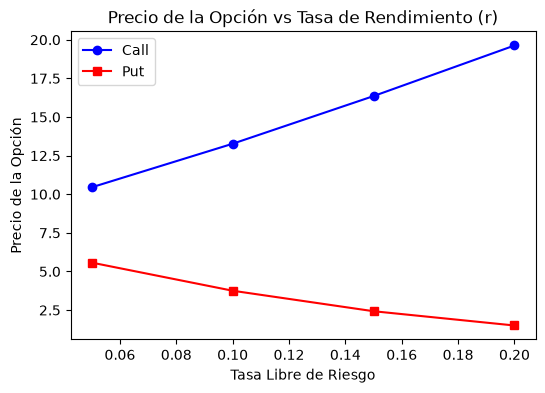

In [39]:
rendimientos = np.array([0.05, 0.10, 0.15, 0.20])

calls_r = [black_scholes(S0, K, T, r, sigma, 'call') for r in rendimientos]
puts_r  = [black_scholes(S0, K, T, r, sigma, 'put') for r in rendimientos]

plt.figure(figsize=(6, 4))
plt.plot(rendimientos, calls_r, marker='o', color='blue', label='Call')
plt.plot(rendimientos, puts_r, marker='s', color='red', label='Put')
plt.title('Precio de la Opción vs Tasa de Rendimiento (r)')
plt.xlabel('Tasa Libre de Riesgo')
plt.ylabel('Precio de la Opción')
plt.legend()
plt.show()

Parte 4. Interpretación

Precio del activo

¿Por qué una call aumenta cuando aumenta el precio de la acción?

Una opción call otorga el derecho a comprar un activo a un precio fijo (K). Si el precio de mercado del activo (S) sube, el derecho a comprarlo más barato de lo que vale en el mercado se vuelve más valioso.

¿Por qué una put se comporta de manera distinta?

Una opción put otorga el derecho a vender un activo a un precio fijo K. Si el precio del activo sube en el mercado, el derecho a venderlo "barato" (a un K que ahora es menor que el precio de mercado) pierde atractivo, por lo que su valor disminuye.

Volatilidad

¿Por qué una mayor incertidumbre aumenta o disminuye el valor de la opción?

Aumenta el valor de ambas opciones (call y put). Las opciones tienen un perfil de riesgo asimétrico, pero el potencial al alza es teóricamente ilimitado (o muy alto para las puts). Una mayor volatilidad significa que la distribución de precios finales es más ancha. Al inversionista no le importan los extremos negativos porque su pérdida está topada en cero (no ejerce la opción), pero sí se beneficia enormemente de los extremos positivos.

Tiempo

¿Siempre es deseable tener más tiempo?

Si el "valor temporal" de una opción representa la probabilidad de que la opción entre in-the-money antes de su vencimiento. A mayor tiempo, mayor oportunidad de que los movimientos del activo subyacente favorezcan al poseedor de la opción.

¿Para quién resulta favorable?

Es favorable para el comprador (tenedor) de la opción. Pero el tiempo juega en contra del vendedor (emisor) de la opción, ya que para el vendedor, cada día que pasa sin que la opción sea ejercida (decaimiento temporal) significa que retiene una mayor parte de la prima.

Strike

Definición de In-the-money (ITM): Una opción está ITM cuando ejercerla en ese instante produciría una ganancia bruta.

Call está ITM si: S > K (El activo vale más de lo que cuesta comprarlo).
Put está ITM si: S < K (El activo vale menos de lo que puedes venderlo).

¿Cómo modifica el strike la probabilidad de terminar in-the-money?

Para una call: Aumentar el strike (K) hace que sea más difícil que el precio del activo supere esa barrera. Entonces, a mayor strike, menor probabilidad de terminar ITM y menor es el precio de la call.

Para una put: Aumentar el strike significa que tienes el derecho a vender a un precio más alto. Es más probable que el precio del activo quede por debajo de un strike alto. Entonces, a mayor strike, mayor probabilidad de terminar ITM y mayor es el precio de la put.

Parte 5. Comparación con el mercado

Si fueras un inversionista, ¿cuál parámetro consideras más importante monitorear? ¿Por qué?

El parámetro más importante a monitorear es la Volatilidad Implícita (sigma), ya que si vemos los cinco parámetros del modelo de Black-Scholes (S, K, T, r, sigma), cuatro de ellos son variables empíricas que puedes observar en el mercado y no son debatibles (conoces el precio actual de la acción, sabes a qué tasa prestan los bancos, y el strike y vencimiento están en tu contrato). 

La volatilidad es la única variable que no es directamente observable en el mercado. Representa la expectativa de los agentes económicos sobre la incertidumbre futura. Si puedes predecir que la volatilidad futura de un activo será mayor a la volatilidad implícita que el mercado está usando actualmente para cotizar la opción, puedes comprar esa opción y generar rendimientos (alpha) cuando el mercado ajuste su percepción de riesgo.